# Analisi dei dataset
Questo notebook contiene il codice sviluppato per l'analisi esplorativa e l'analisi del drift sui dataset scelti per il progetto.

## Import e setup

In [1]:
import os
import random
from pathlib import Path
from collections import Counter, defaultdict
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datasets import load_from_disk
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import pdist
from tqdm import tqdm
from evidently import Report
from evidently.presets import DataDriftPreset
from utils.drift_utils import *


In [2]:
ORIGINAL_DIR = Path("../original_datasets") # Original datasets folder
PREPROC_DIR = Path("../preprocessed_datasets") # Preprocessed datasets folder
BASE_OUT_DIR = Path("../eda_outputs") # Output dir where to put the plots images
# Create the output di if it does not exists
BASE_OUT_DIR.mkdir(exist_ok=True)
# Get the maximum number of threads available
NUM_PROC = max(1, (os.cpu_count() or 1) - 1)
# Batch size for batch jobs
BATCH_SIZE = 128

## Preprocessing
Prima di procedere con un’analisi più approfondita dei dataset, abbiamo raccolto alcune informazioni preliminari su di essi e svolto una fase di pre-processing, finalizzata a rendere i dati maggiormente omogenei e confrontabili. In particolare:
- Abbiamo effettuato il mapping delle classi di ImageNet-R, originariamente espresse tramite WordNet ID (WNID), alle corrispondenti classi di ImageNet-1k, identificate tramite ID numerici compresi tra 0 e 999.
- Poiché ImageNet-R presenta uno sbilanciamento nella distribuzione delle classi, abbiamo applicato un troncamento a 50 esempi per classe, in modo da ottenere una distribuzione comparabile con quella di ImageNet-1k e limitare l’introduzione di un ulteriore data distribution drift che avrebbe potuto influenzare la valutazione delle prestazioni del modello.
- Abbiamo suddiviso ImageNet-C in diversi dataset, ciascuno corrispondente a una specifica tipologia di corruzione e al relativo livello di severità, così da poter analizzare separatamente l’impatto delle diverse perturbazioni sulle prestazioni del modello.

Il codice sviluppato per la fase di pre-processing è posto nella cartella [data_preprocess](../data_preprocess/datasets_preprocess.py) di questa repository ed è necessario eseguirlo prima di utilizzare questo notebook.

### Caricamento dei dataset

In [3]:
imagenet_r_raw = load_from_disk(ORIGINAL_DIR / "imagenet_r") # Original imagenet-r
imagenet_1k_raw = load_from_disk(ORIGINAL_DIR / "imagenet-1k") # Original imagenet-1k
imagenet_r_pre = load_from_disk(PREPROC_DIR / "imagenet_r_preprocessed") # Preprocessed imagenet-r (50 ex. per class)
imagenet_1k_pre = load_from_disk(PREPROC_DIR / "imagenet_1k_preprocessed") # Preprocessed imagenet-1k (200 classes)

# Load imagenet-c datasets into a dictionary
imagenet_c_dir = ORIGINAL_DIR / "imagenet_c_datasets"

imagenet_c = {
    f"ImageNet-C ({dataset_dir.name})": load_from_disk(dataset_dir)
    for dataset_dir in sorted(imagenet_c_dir.iterdir())
    if dataset_dir.is_dir()
}

# Collect all datasets into a flat dictionary with the class column
datasets_dict = {
    "ImageNet-R (raw)": (imagenet_r_raw, "wnid"),
    "ImageNet-1k val (raw)": (imagenet_1k_raw, "label"),
    "ImageNet-R (preprocessed)": (imagenet_r_pre, "label"),
    "ImageNet-1k val (preprocessed, 200 classi)": (imagenet_1k_pre, "label"),
}

for name, dataset in imagenet_c.items():
    datasets_dict[name] = (dataset, "label")


## Analisi esplorativa
Questa sezione del notebook contiene il codice sviluppato per l'analisi esplorativa dei dataset selezionati.

### Struttura dei dataset e distribuzione per classe
Iniziamo analizzando la struttura di ogni dataset:

In [4]:
for name, (ds, _) in datasets_dict.items():
    print(f"\n{name}")
    print(ds)


ImageNet-R (raw)
Dataset({
    features: ['image', 'wnid', 'class_name'],
    num_rows: 30000
})

ImageNet-1k val (raw)
Dataset({
    features: ['image', 'label'],
    num_rows: 50000
})

ImageNet-R (preprocessed)
Dataset({
    features: ['image', 'wnid', 'class_name', 'label'],
    num_rows: 10000
})

ImageNet-1k val (preprocessed, 200 classi)
Dataset({
    features: ['image', 'label'],
    num_rows: 10000
})

ImageNet-C (brightness_sev_1)
Dataset({
    features: ['image', 'wnid', 'label'],
    num_rows: 50000
})

ImageNet-C (brightness_sev_2)
Dataset({
    features: ['image', 'wnid', 'label'],
    num_rows: 50000
})

ImageNet-C (brightness_sev_3)
Dataset({
    features: ['image', 'wnid', 'label'],
    num_rows: 50000
})

ImageNet-C (brightness_sev_4)
Dataset({
    features: ['image', 'wnid', 'label'],
    num_rows: 50000
})

ImageNet-C (brightness_sev_5)
Dataset({
    features: ['image', 'wnid', 'label'],
    num_rows: 50000
})

ImageNet-C (contrast_sev_1)
Dataset({
    features: ['

Analizziamo inoltre la distribuzione per classe: iniziamo confrontando la distribuzione di imagenet-r con quella di imagenet-1k preprocessato a 200 classi:

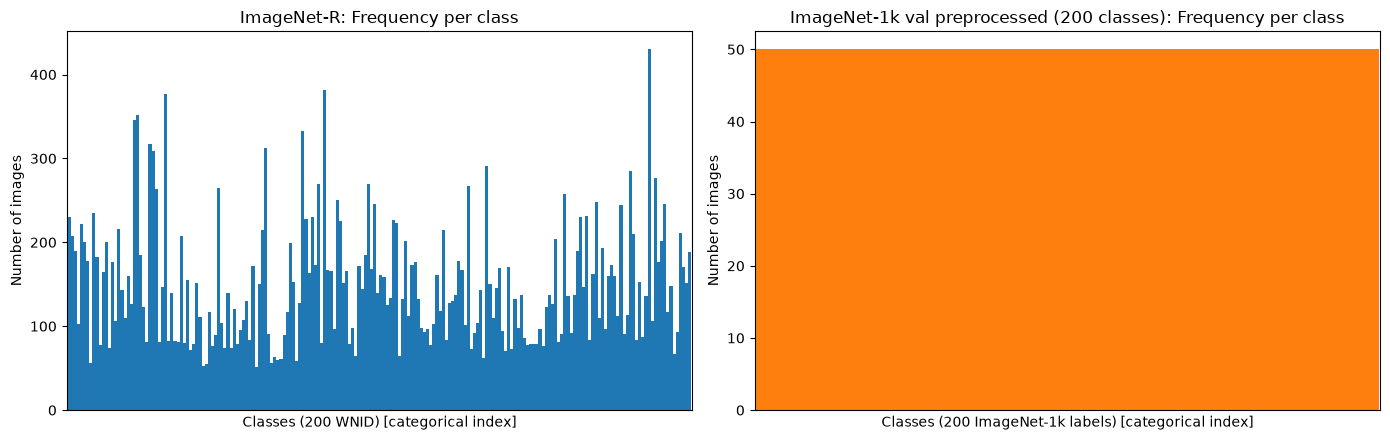

In [5]:
# Compute per-class image counts for the raw ImageNet-R set
r_dist = class_distribution(imagenet_r_raw, "wnid", "ImageNet-R (raw)")

# Compute per-class image counts for the preprocessed ImageNet-1k subset
ik_pre_dist = class_distribution(imagenet_1k_pre, "label", "ImageNet-1k preprocessed")

# Directory where distribution plots will be saved
DISTR_OUT_DIR = BASE_OUT_DIR / "distributions"
DISTR_OUT_DIR.mkdir(exist_ok=True)

# Side-by-side bar charts comparing class frequency in ImageNet-R vs ImageNet-1k preprocessed
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left panel: ImageNet-R class distribution
r_dist.plot(kind="bar", ax=axes[0], width=1.0, color="#1f77b4")
axes[0].set_title("ImageNet-R: Frequency per class")
axes[0].set_xticks([])  # hide x-tick labels since there are 200 classes (too many to display)
axes[0].set_xlabel("Classes (200 WNID) [categorical index]")
axes[0].set_ylabel("Number of images")

# Right panel: ImageNet-1k (matching 200-class subset) distribution
ik_pre_dist.plot(kind="bar", ax=axes[1], width=1.0, color="#ff7f0e")
axes[1].set_title("ImageNet-1k val preprocessed (200 classes): Frequency per class")
axes[1].set_xticks([])  # same reasoning: suppress noisy x-axis labels
axes[1].set_xlabel("Classes (200 ImageNet-1k labels) [categorical index]")
axes[1].set_ylabel("Number of images")

plt.tight_layout()

# Save the comparison figure to disk
plt.savefig(DISTR_OUT_DIR / "imagenet-r-raw_vs_imagenet-1k-pre.png", dpi=150)
plt.show()

Come si può vedere dal grafico sopra riportato, imagenet-r ha una distribuzione degli esempi per classe sbilanciata. Per evitare ulteriore drift, abbiamo quindi deciso di ridurre gli esempi di imagenet-r a 50 per classe, ottenendo quindi una distribuzione bilanciata:

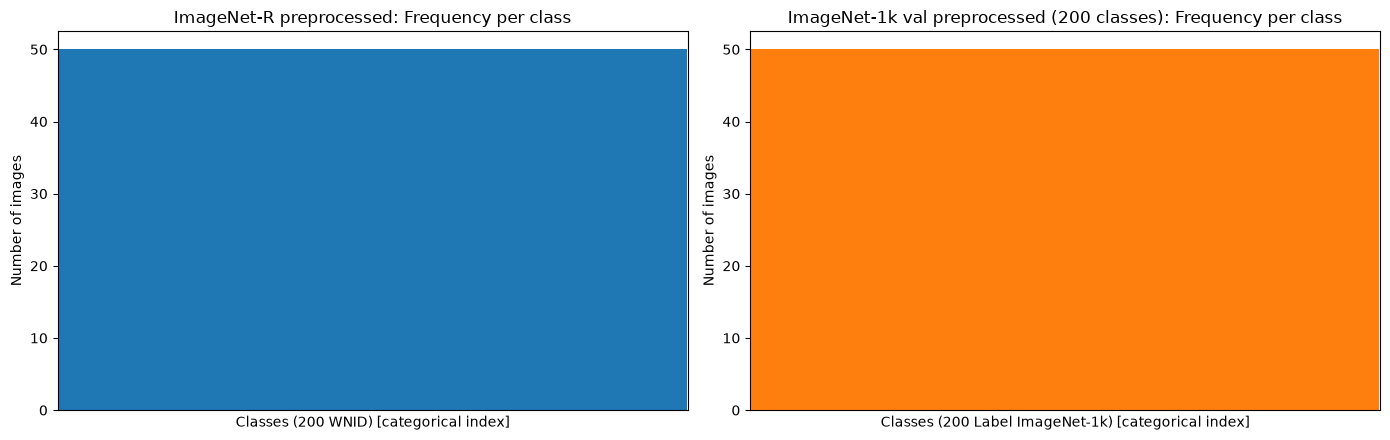

In [6]:
# Compute per-class image counts for the preprocessed ImageNet-R set
r_dist = class_distribution(imagenet_r_pre, "label", "ImageNet-R (preprocessed)")

# Compute per-class image counts for the preprocessed ImageNet-1k subset
ik_pre_dist = class_distribution(imagenet_1k_pre, "label", "ImageNet-1k preprocessed")

# Side-by-side bar charts comparing class frequency in ImageNet-R vs ImageNet-1k (200-class subset)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left panel: ImageNet-R class distribution
r_dist.plot(kind="bar", ax=axes[0], width=1.0, color="#1f77b4")
axes[0].set_title("ImageNet-R preprocessed: Frequency per class")
axes[0].set_xticks([])  # hide x-tick labels since there are 200 classes (too many to display)
axes[0].set_xlabel("Classes (200 WNID) [categorical index]")
axes[0].set_ylabel("Number of images")

# Right panel: ImageNet-1k preprocessed distribution
ik_pre_dist.plot(kind="bar", ax=axes[1], width=1.0, color="#ff7f0e")
axes[1].set_title("ImageNet-1k val preprocessed (200 classes): Frequency per class")
axes[1].set_xticks([])  # same reasoning: suppress noisy x-axis labels
axes[1].set_xlabel("Classes (200 Label ImageNet-1k) [categorical index]")
axes[1].set_ylabel("Number of images")

plt.tight_layout()

# Save the comparison figure to disk
plt.savefig(DISTR_OUT_DIR / "imagenet-r-pre_vs_imagenet-1k-pre.png", dpi=150)
plt.show()

Controlliamo inoltre che le classi coincidano tra i due dataset:

In [7]:
# Set of distinct WNIDs (WordNet IDs) present in the raw ImageNet-R dataset
r_wnids = set(imagenet_r_raw["wnid"])
# Set of ImageNet-1k label indices covered by ImageNet-R (after WNID -> label mapping)
r_ik_labels = set(imagenet_r_pre["label"])
# Set of label indices present in the preprocessed ImageNet-1k subset
ik_pre_labels = set(imagenet_1k_pre["label"])
print(f"\nDistinct WNIDs in ImageNet-R: {len(r_wnids)}")
print(f"ImageNet-1k indices covered by ImageNet-R (via mapping): {len(r_ik_labels)}")
print(f"Indices present in preprocessed ImageNet-1k: {len(ik_pre_labels)}")
print(f"The two index sets match exactly: {r_ik_labels == ik_pre_labels}")
# If the two sets don't match, show which indices differ between them
if r_ik_labels != ik_pre_labels:
    print("Difference:", r_ik_labels.symmetric_difference(ik_pre_labels))


Distinct WNIDs in ImageNet-R: 200
ImageNet-1k indices covered by ImageNet-R (via mapping): 200
Indices present in preprocessed ImageNet-1k: 200
The two index sets match exactly: True


Analizziamo ora le distribuzioni dei dataset ottenuti dalla suddivisone di imagenet-c:

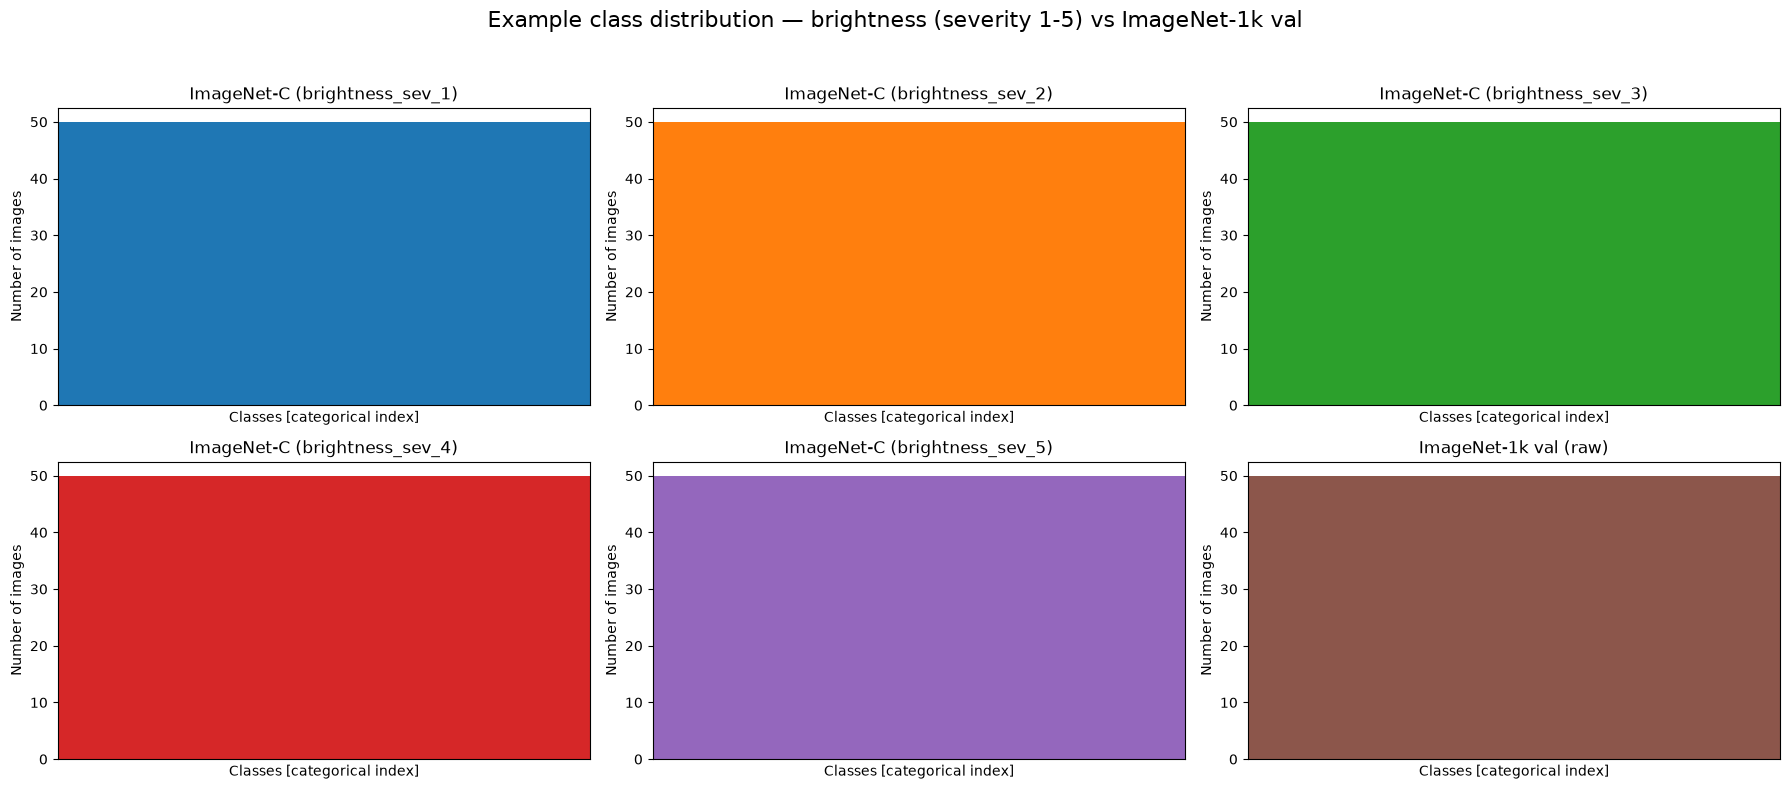

In [8]:
all_names = sorted(imagenet_c.keys())

# Extract the folders names from the ImageNet-C dictionary
folder_names = {key: extract_folder_name(key) for key in all_names}

# Separate corruption severity from the folder's name
parsed = {key: split_corruption_severity(name) for key, name in folder_names.items()}

# Choose the first corruption type with 5 levels of severity available
by_corruption = defaultdict(dict)
for key, (corruption, severity) in parsed.items():
    if severity is not None:
        by_corruption[corruption][severity] = key

# Prepare example
example_corruption = next(
    (c for c, sevs in by_corruption.items() if len(sevs) >= 5), None
)

# Handle case where the dataset was not generated correctly
if example_corruption is None:
    raise ValueError(
        "No corruption with 5 severity levels found. "
        f"Detected key format: {list(folder_names.values())[:5]}"
    )

# Array with the names for the example plot
example_names = [by_corruption[example_corruption][s] for s in sorted(by_corruption[example_corruption])[:5]]

# Plot colors
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# Create example figure (5 corruption severities + 1 ImageNet-1k val raw baseline), 3 plots per row
n_cols = 3
n_plots = len(example_names) + 1  # +1 for the ImageNet-1k val raw baseline
n_rows = math.ceil(n_plots / n_cols)

example_fig, example_axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
example_axes = example_axes.reshape(n_rows, n_cols)

# Create the figure plots for the 5 corruption severity levels
for i, name in enumerate(example_names):
    dataset = imagenet_c[name]
    # Get the class distribution
    dist = class_distribution(dataset, "label", name)

    # Setup the plot
    row, col = divmod(i, n_cols)
    ax = example_axes[row, col]
    dist.plot(kind="bar", ax=ax, width=1.0, color=colors[i % len(colors)])
    ax.set_title(f"{name}")
    ax.set_xticks([])
    ax.set_xlabel("Classes [categorical index]")
    ax.set_ylabel("Number of images")

# Add ImageNet-1k val
ik_raw_dist = class_distribution(imagenet_1k_raw, "label", "ImageNet-1k val")
row, col = divmod(len(example_names), n_cols)
ax = example_axes[row, col]
ik_raw_dist.plot(kind="bar", ax=ax, width=1.0, color=colors[5])
ax.set_title("ImageNet-1k val (raw)")
ax.set_xticks([])
ax.set_xlabel("Classes [categorical index]")
ax.set_ylabel("Number of images")

# Hide any unused axes if n_plots is not a multiple of n_cols
for idx in range(n_plots, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    example_axes[row, col].set_visible(False)

example_fig.suptitle(
    f"Example class distribution — {example_corruption} (severity 1-5) vs ImageNet-1k val",
    fontsize=16
)
example_fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()
example_fig.savefig(DISTR_OUT_DIR / "imagenet-c-distribution-examples.png", dpi=150)

Come si può notare dal grafico riportato, ImageNet-C contiene 50 immagini per ogni livello di corruzione e per ognuna delle 1000 classi di imagenet-1k. Data la numerosità delle suddivisioni del dataset, il grafico riportato sopra è solo a titolo di esempio.


## Analisi del drift
Per analizzare l'avvenimento di un data drift rispetto ad imagenet-1k, ci avvarremo di un test statistico (Distanza di Wesserstein) sulle seguenti misure:
- Luminanza
- Contrasto
- Nitidezza (Sharpness)
- Media dei canali colore

Non terremo invece in considerazione le misure riguardanti la risoluzione delle immagini, visto che il pre-processing del modello ResNet50 impone il ridimensionamento dell'immagine ad una risoluzione di 224x224 px

### Distanza di Wesserstein
La distanza di Wesserstein, o "Earth Mover's Distance", è una metrica che indica, in valori assoluti, il valore di un data drift tra due distribuzioni di probabilità. Essa misura la quantità di "sforzo" necessaria a trasformare una distribuzione nell'altra.

La libreria Evidently normalizza la distanza calcolata dividendola per la deviazione standard, in modo da ottenere dei valori comparabili per feature e per porre una soglia oltre la quale viene rilevato un data drift.

### ImageNet-R vs ImageNet-1k

Proviamo ad applicare il test ad ImageNet1k e ImageNet-R:

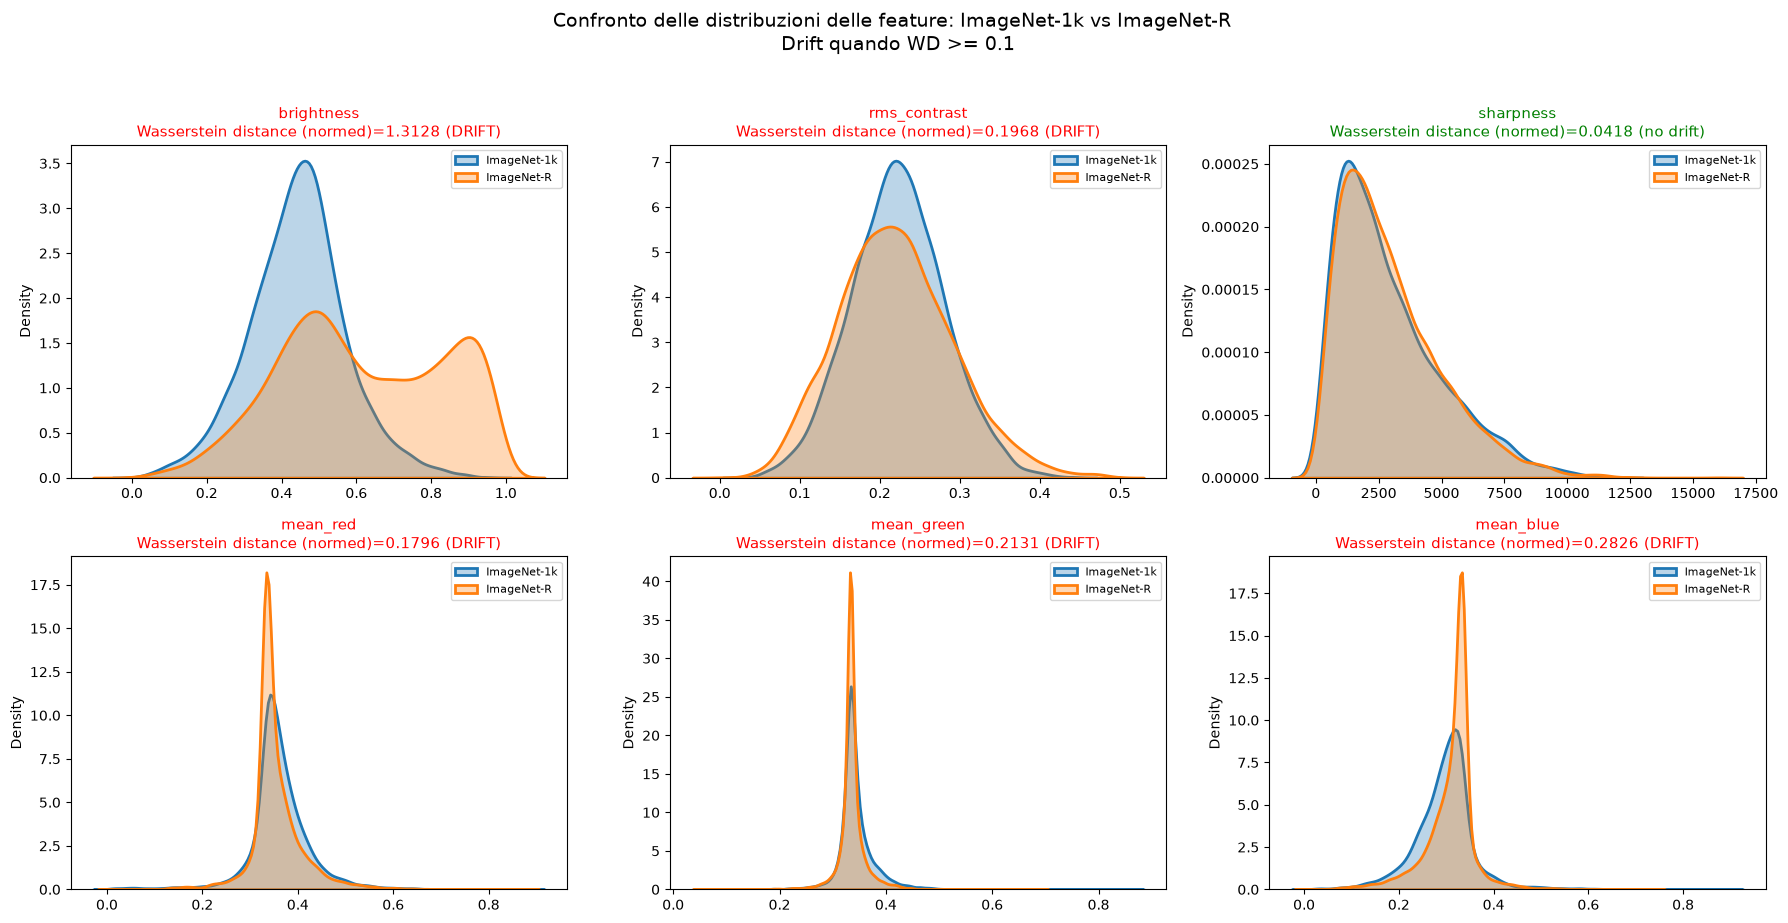

In [9]:
PROPERTIES_OUT_DIR = BASE_OUT_DIR / "properties_files"
PROPERTIES_OUT_DIR.mkdir(parents=True, exist_ok=True)
# Extract the numerical features of the image
imagenet_1k_props = extract_properties(imagenet_1k_pre, cache_path=PROPERTIES_OUT_DIR / "imagenet_1k_preprocessed_props.csv")
imagenet_r_props = extract_properties(imagenet_r_pre, cache_path=PROPERTIES_OUT_DIR / "imagenet_r_props.csv")

# Run the test and obtain the results
report = Report(metrics=[DataDriftPreset()])
result = report.run(reference_data=imagenet_1k_props, current_data=imagenet_r_props)

# Extract metrics from test results
drift_info = extract_drift_info(result)

DRIFT_INFO_OUT_DIR = BASE_OUT_DIR / "drift_info"
DRIFT_INFO_OUT_DIR.mkdir(parents=True, exist_ok=True)
# Plot
fig = plot_drift_info(
    imagenet_1k_props,
    imagenet_r_props,
    drift_info,
    ref_label="ImageNet-1k",
    cur_label="ImageNet-R",
    save_path=DRIFT_INFO_OUT_DIR / "drift_distr_imagenet-1k_vs_imagenet-r.png",)

Come si può evincere dal grafico, la maggior parte delle feature presenta un drift rispetto all adistribuzione di riferimento (imagenet-1k) secondo la distanza di Wesserstein

### ImageNet-1k vs ImageNet-C

Calcoliamo ora le proprietà visive di imagenet-1k completo e di ogni sotto-dataset di imagenet-C

In [10]:
imagenet_1k_props = extract_properties(imagenet_1k_raw, cache_path=PROPERTIES_OUT_DIR / "imagenet_1k_props.csv")

In [11]:
DRIFT_TABLE_DIR = BASE_OUT_DIR / "drift_tables"
DRIFT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
drift_table = build_drift_table(imagenet_c, imagenet_1k_props, cache_path=DRIFT_TABLE_DIR / "imagenet_c_drift_table.csv")

In [12]:
FEATURE_TABLE_DIR = BASE_OUT_DIR / "feature_tables"
FEATURE_TABLE_DIR.mkdir(parents=True, exist_ok=True)
feature_table = build_feature_table(
    imagenet_c, imagenet_1k_props,
    cache_path=FEATURE_TABLE_DIR / "imagenet_c_feature_table.csv",
)

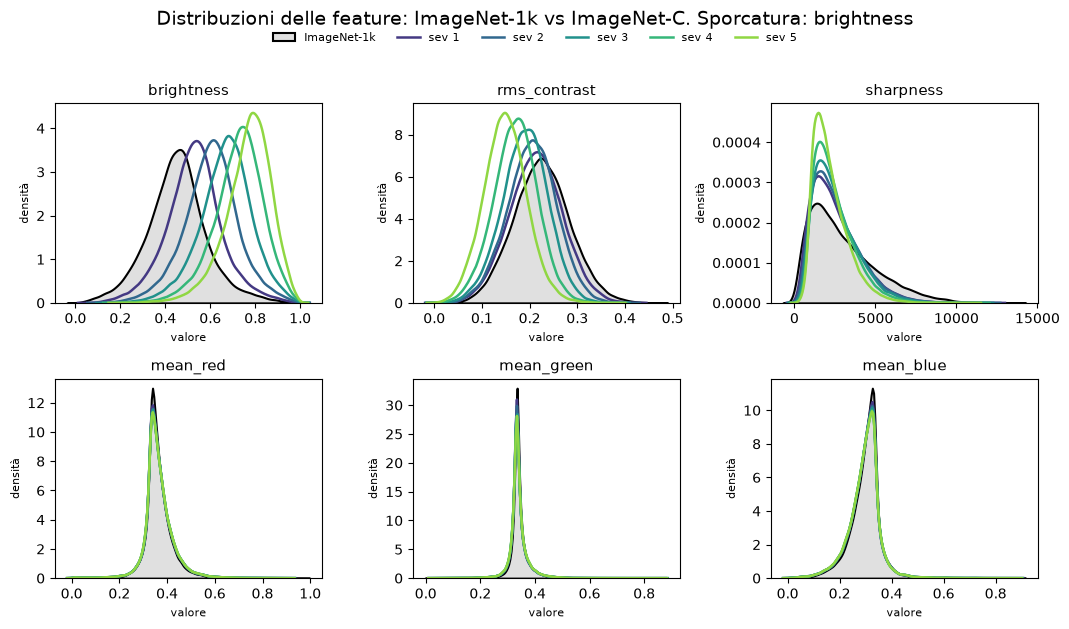

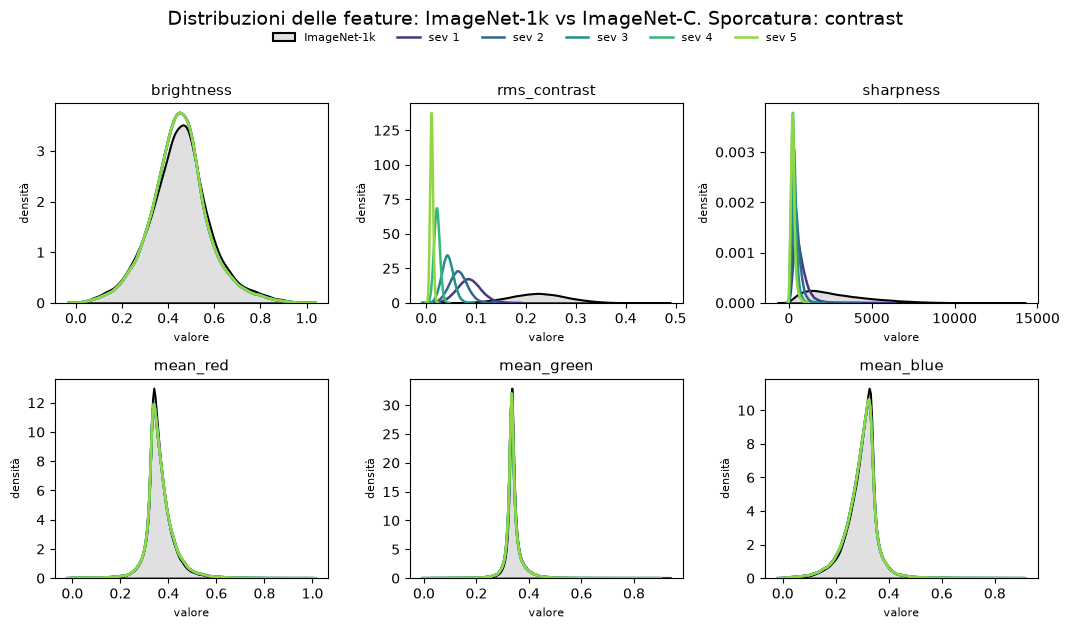

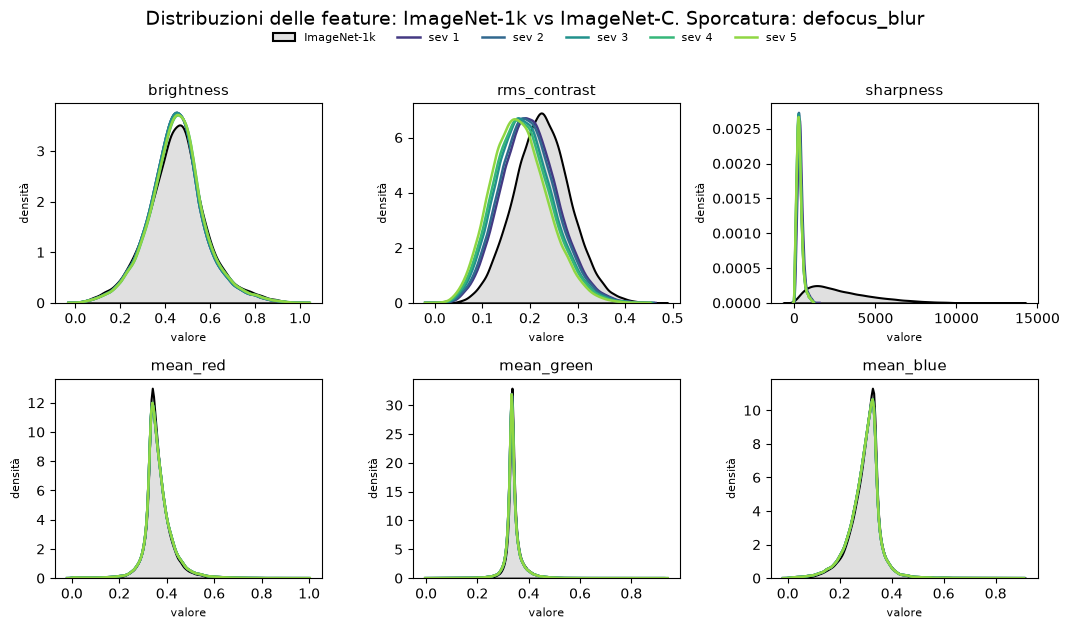

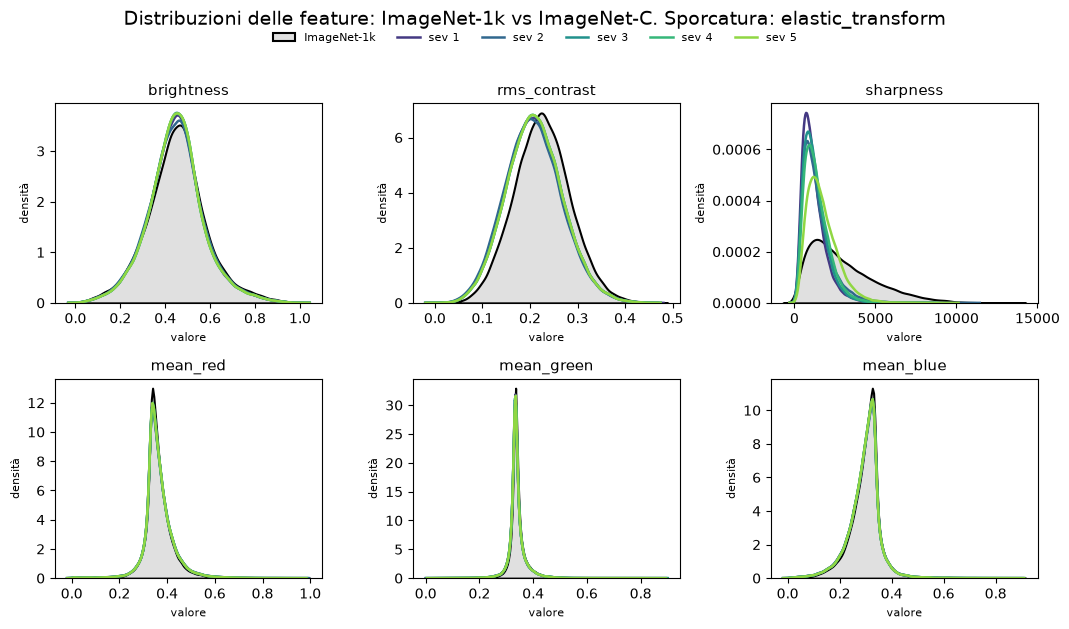

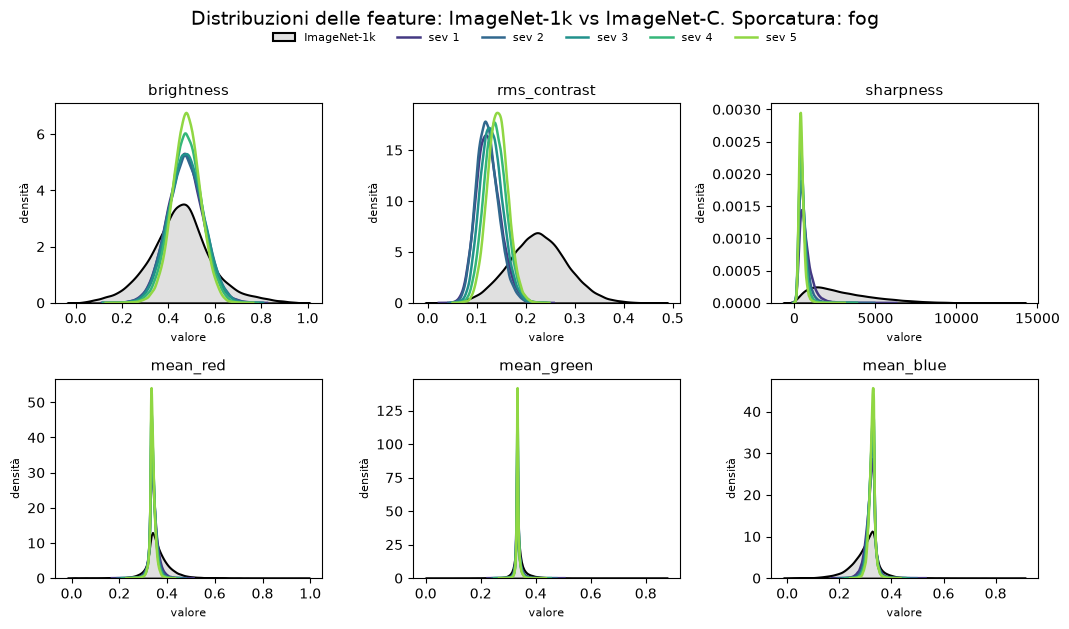

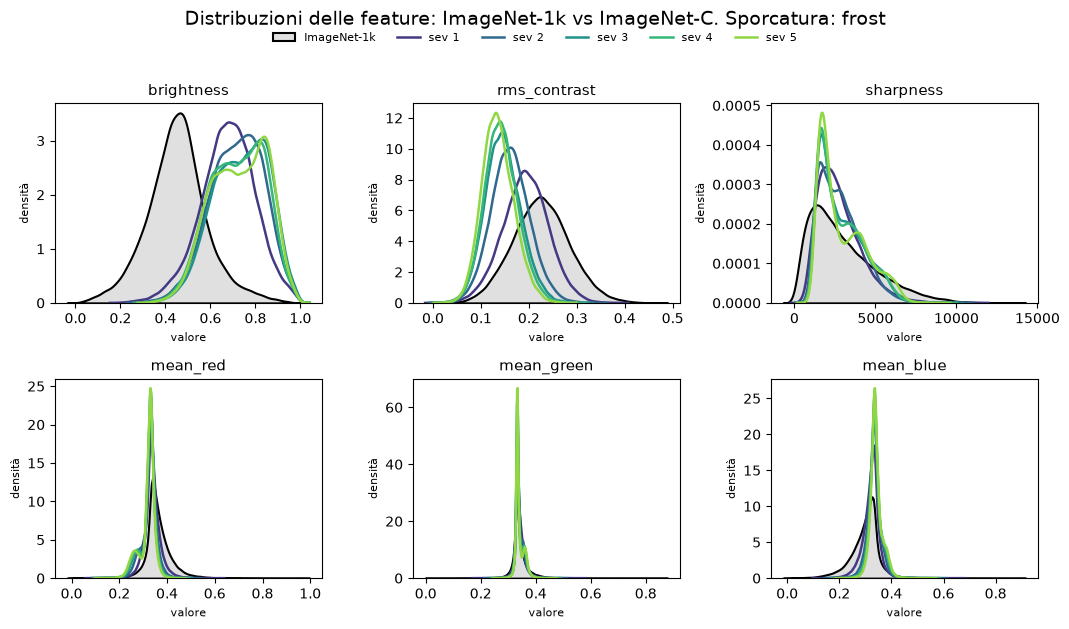

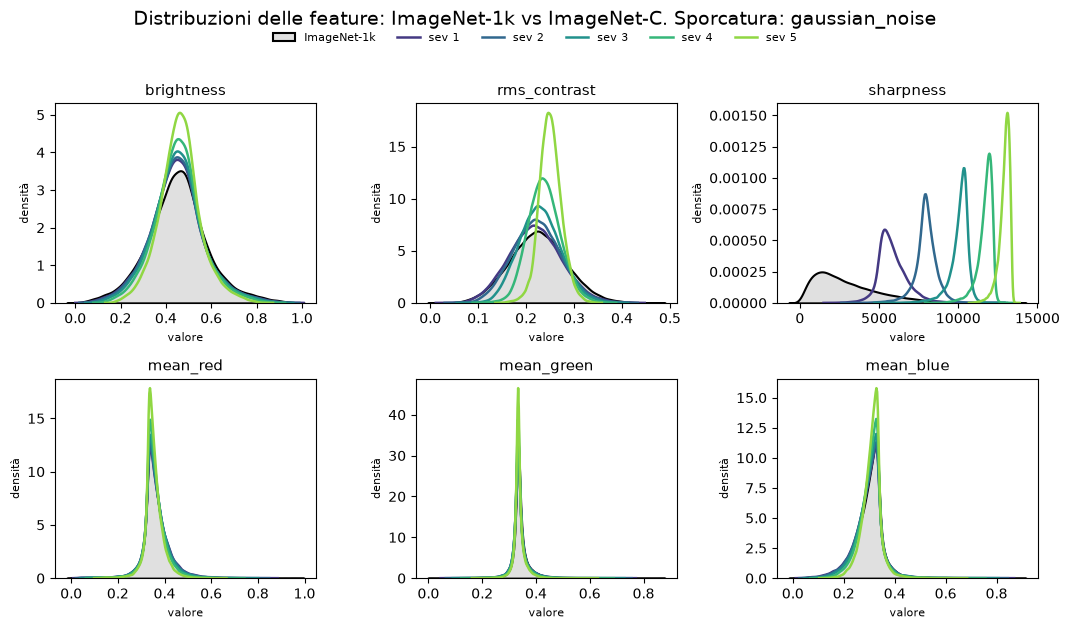

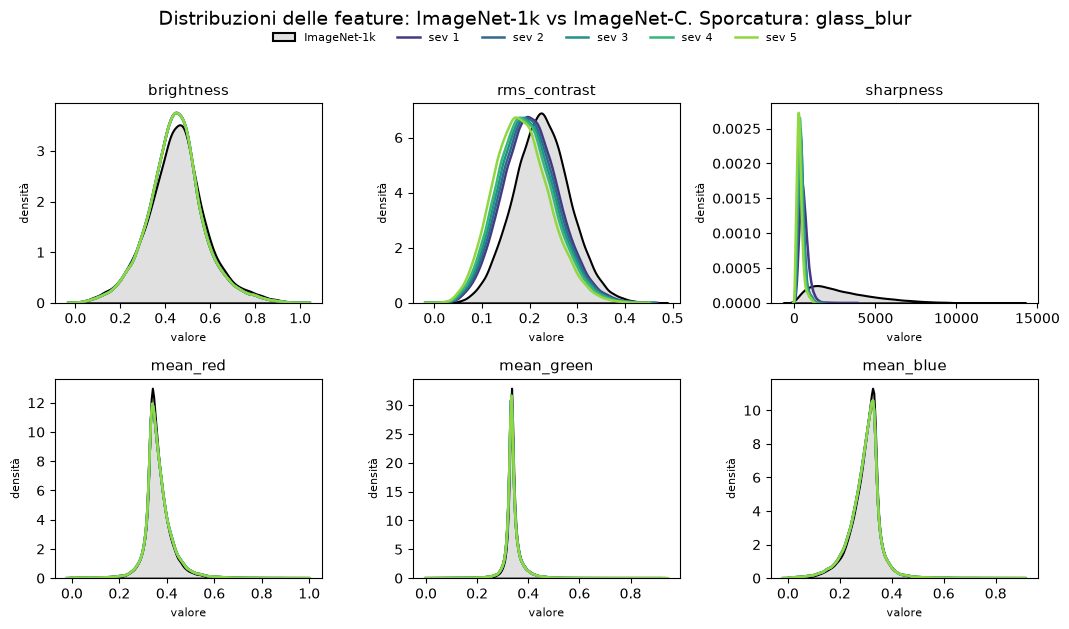

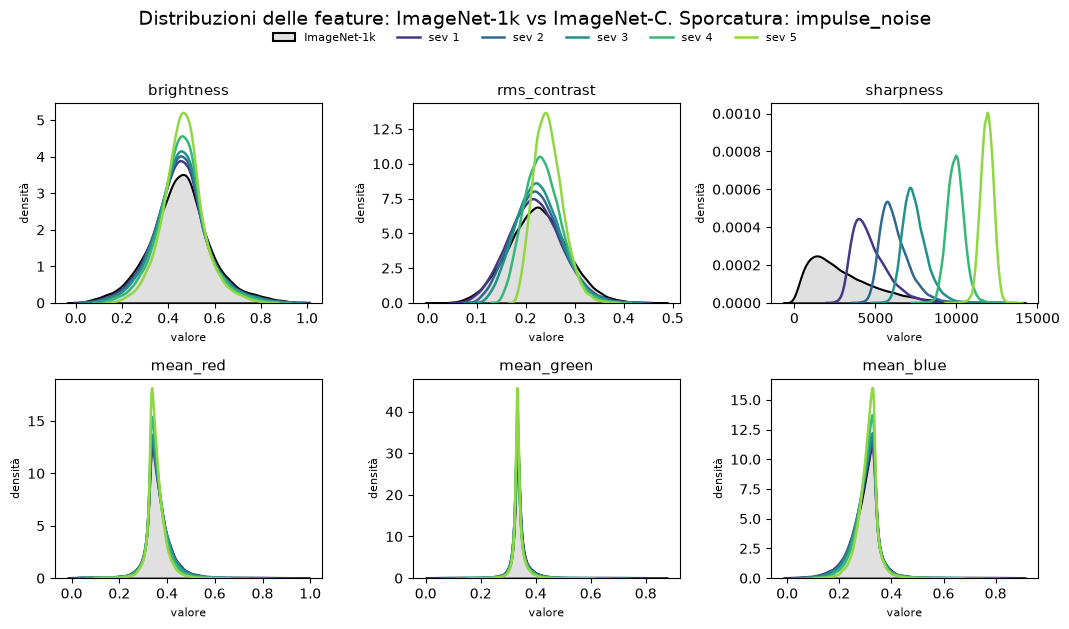

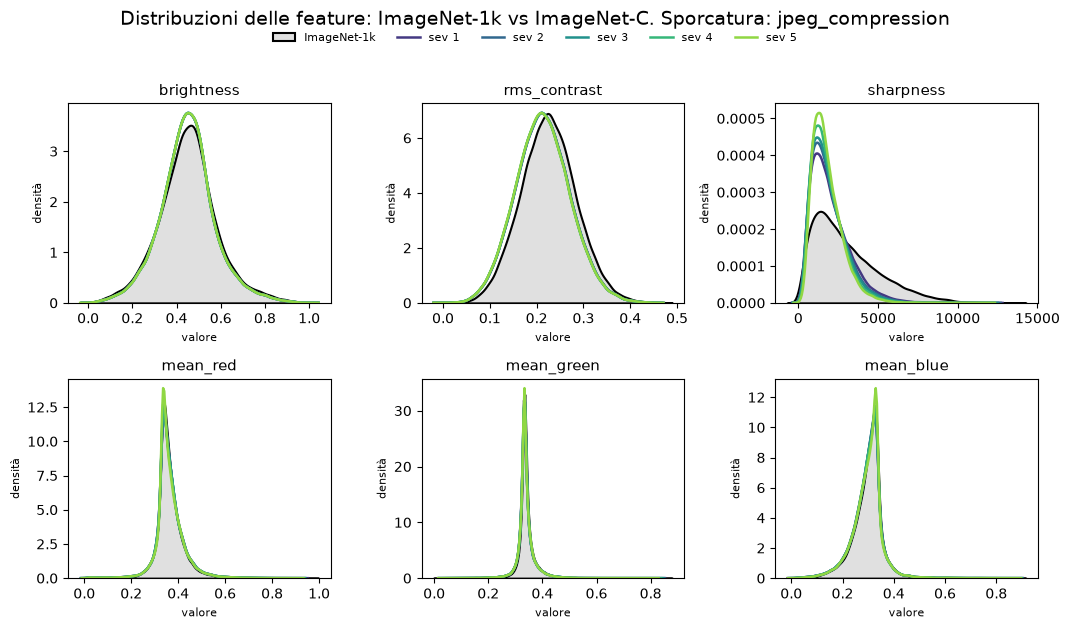

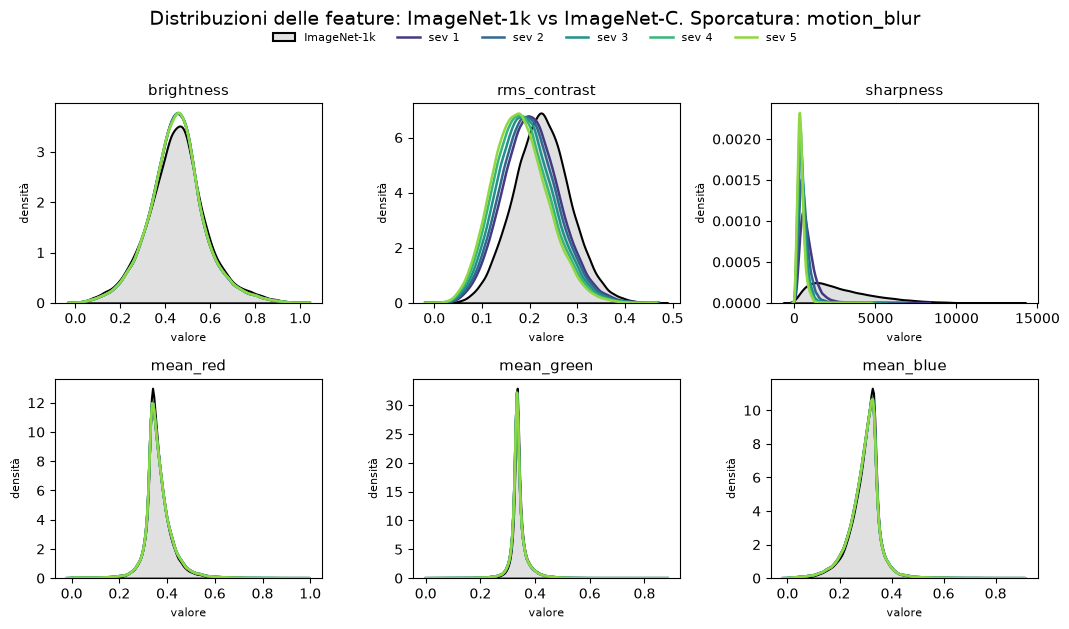

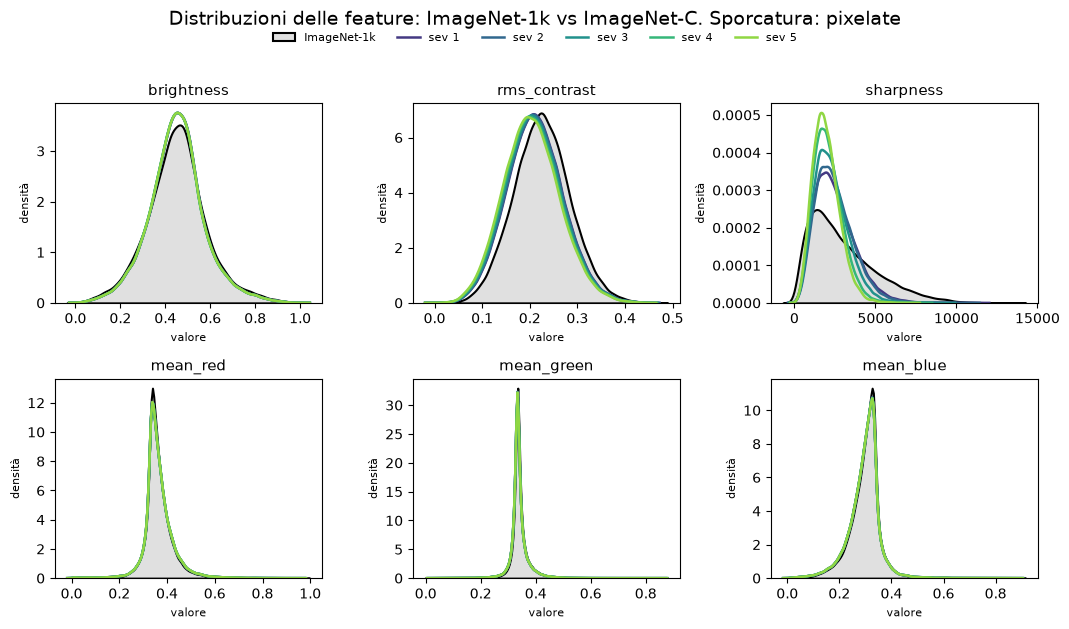

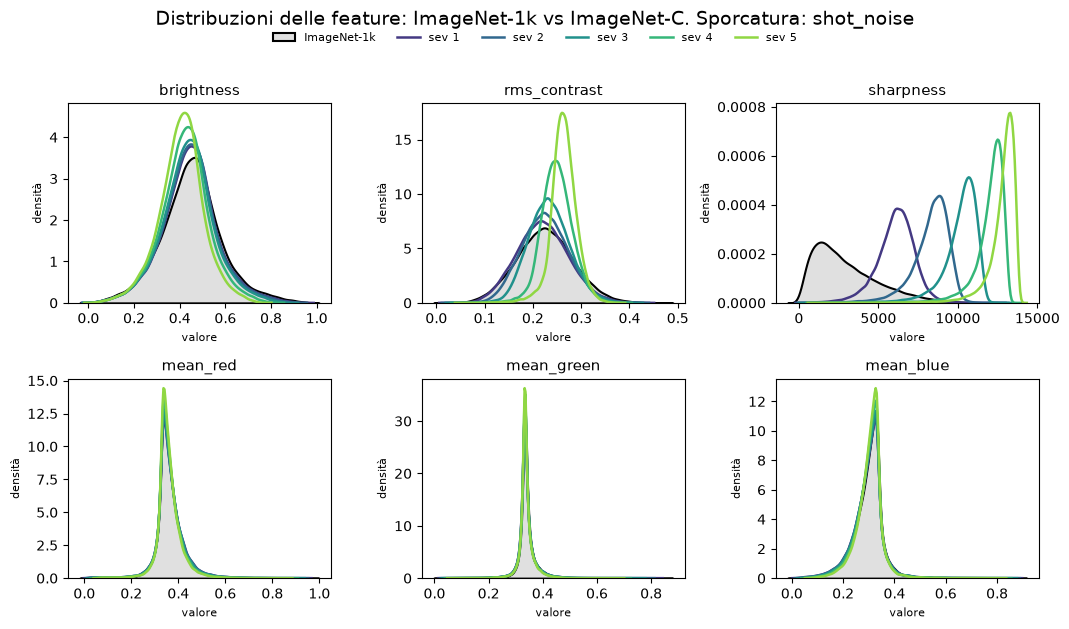

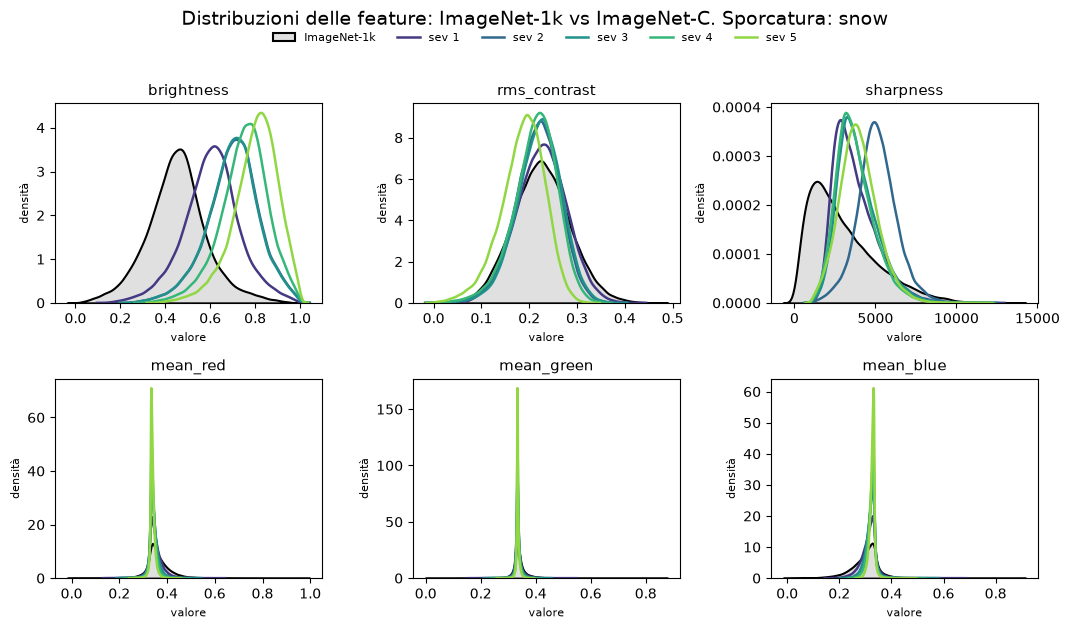

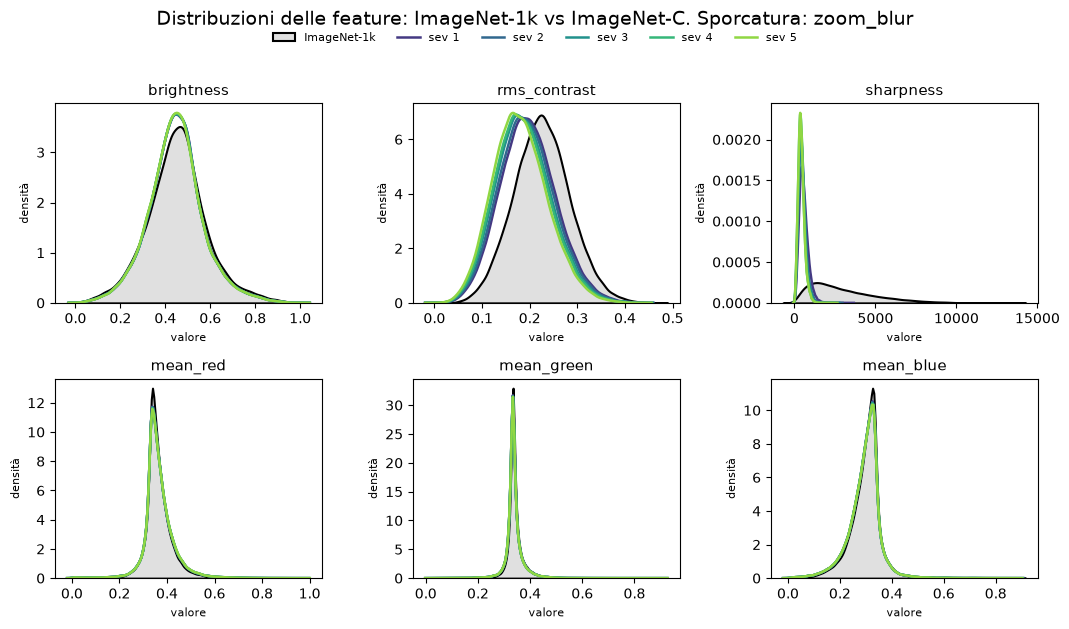

In [14]:
DISTRIBUTION_BY_CORRUPTION_OUT_DIR = BASE_OUT_DIR / "distributions_by_corruption"
DISTRIBUTION_BY_CORRUPTION_OUT_DIR.mkdir(parents = True, exist_ok = True)
figs = plot_distributions_by_corruption(feature_table, save_dir = DISTRIBUTION_BY_CORRUPTION_OUT_DIR)

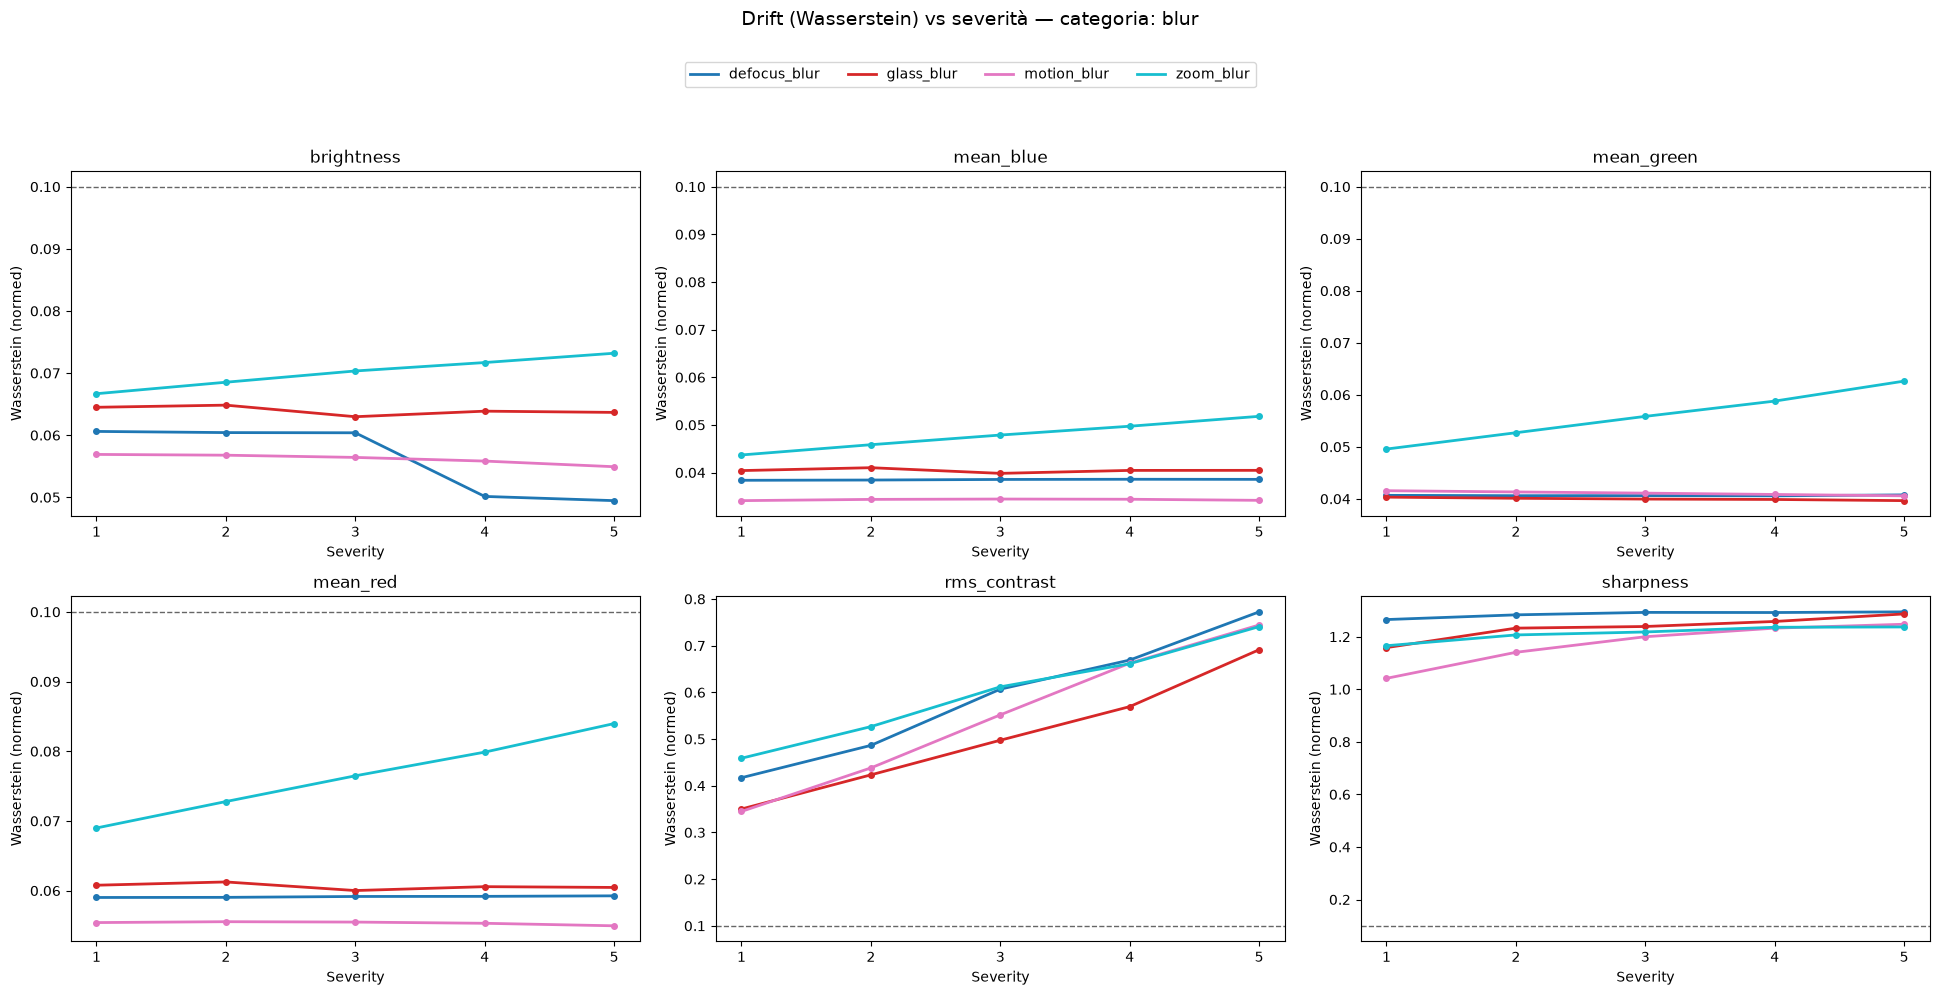

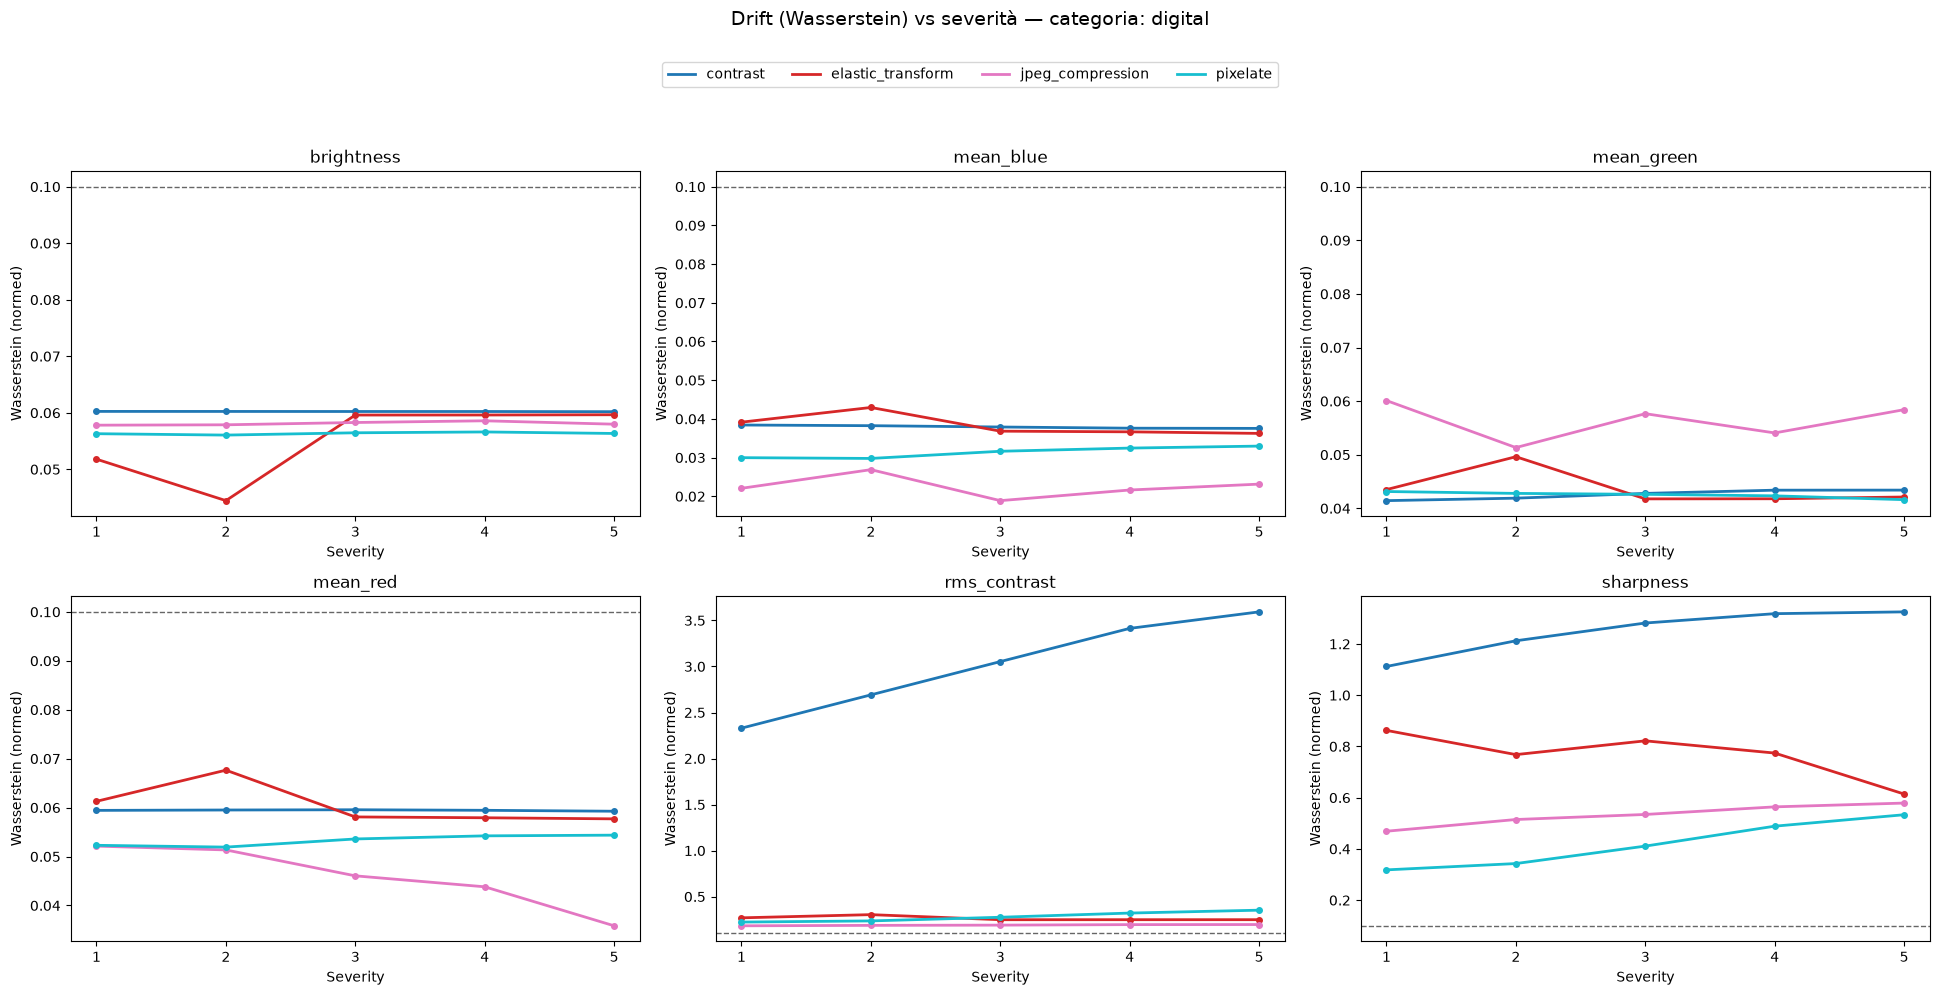

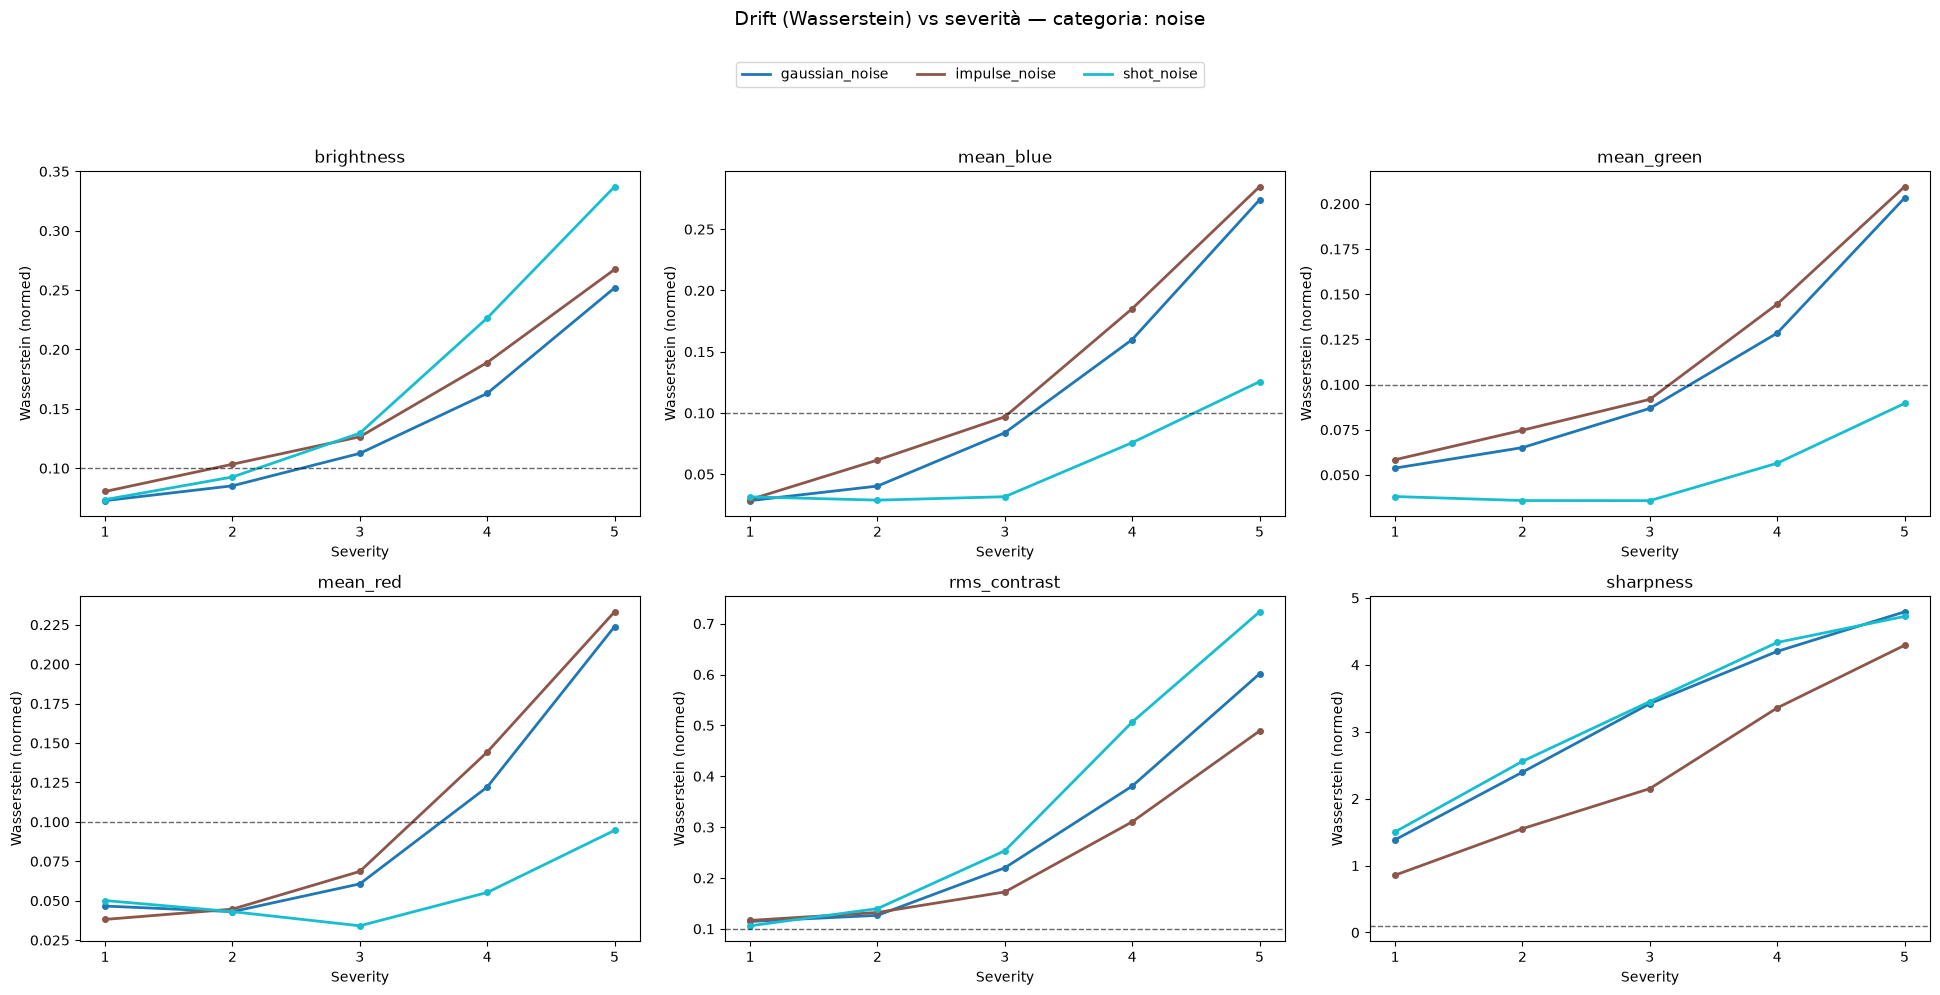

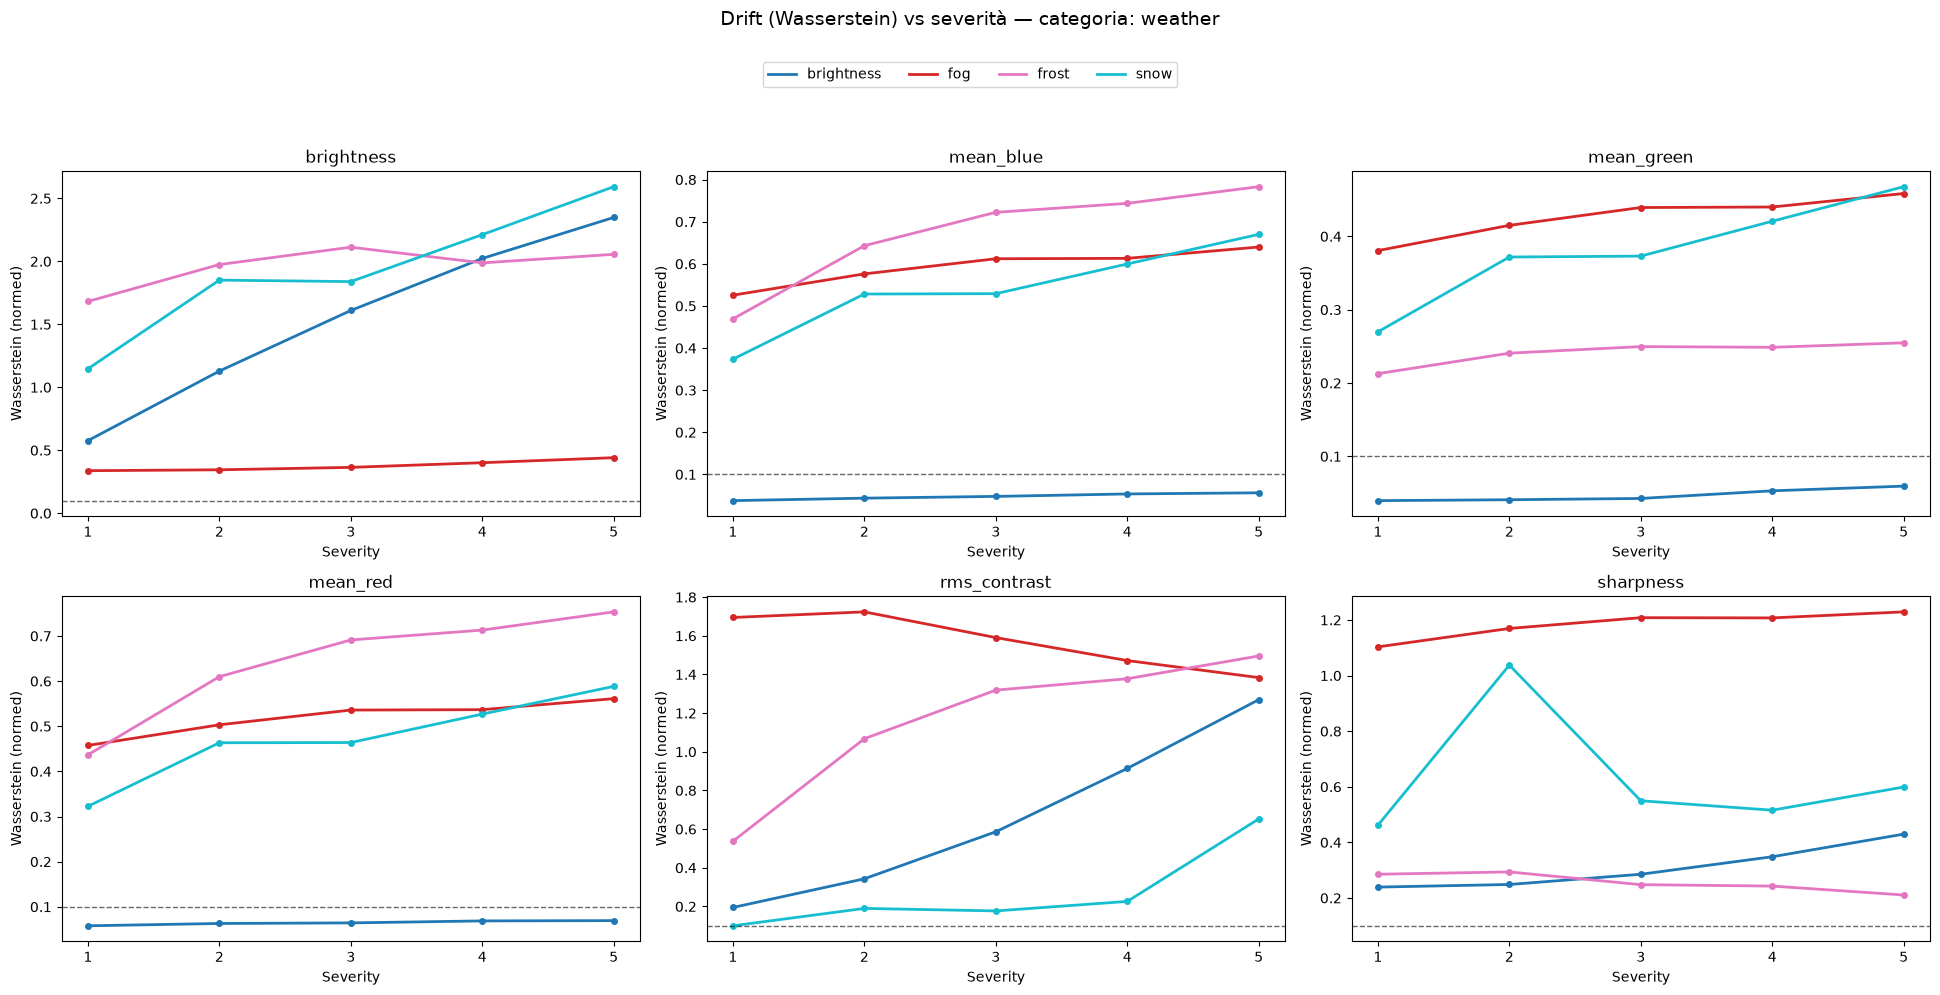

In [15]:
SEVERITY_CURVES_OUT_DIR = BASE_OUT_DIR / "severity_curves"
SEVERITY_CURVES_OUT_DIR.mkdir(parents = True, exist_ok = True)
figs = plot_severity_curves_by_category(drift_table, save_dir = SEVERITY_CURVES_OUT_DIR)